In [3]:
from matplotlib import pyplot as plt
import numpy as np

from wannierberri.system import System_PythTB
import ray
ray.init()
from wannierberri.models import Haldane_ptb
system = System_PythTB(Haldane_ptb())


2026-02-17 18:34:32,192	INFO worker.py:1918 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (7, 2, 2)
Real-space lattice:
 [[1.        0.        0.       ]
 [0.5       0.8660254 0.       ]
 [0.        0.        1.       ]]
Number of wannier functions: 2
Number of R points: 7
Recommended size of FFT grid [3 3 1]
Reading the system from PythTB finished successfully


In [15]:
from wannierberri.calculators.static import DOS, Ohmic_FermiSea
from wannierberri.calculators.tabulate import TabulatorAll 
from wannierberri import run
from wannierberri.grid import Grid


NK=100
from wannierberri.models import Haldane_ptb, Chiral
calculators = {}

Efermi = np.linspace(-5, 5, 101)
calculators["dos"] = DOS(Efermi=Efermi, tetra=True)
calculators["ohmic"] = Ohmic_FermiSea(Efermi=Efermi, tetra=True)
calculators["tabulate"] = TabulatorAll(tabulators={})
grid = Grid(system, NK=100, NKFFT=10)

results = run(system, calculators=calculators, grid=grid)

Starting run()
Using the follwing calculators : 
############################################################

 'dos'  :  <wannierberri.calculators.static.DOS object at 0x78c44c7c0ce0>  : Density of states
 'ohmic'  :  <wannierberri.calculators.static.Ohmic_FermiSea object at 0x78c44c414a70>  : Ohmic conductivity (:math:`S/m`)

        | With Fermi sea integral. Eq(31) in `Ref <https://www.nature.com/articles/s41524-021-00498-5>`__
        | Output: :math:`\sigma_{\alpha\beta} = e^2/\hbar \tau \int [dk] \partial_\beta v_\alpha f`for \tau=1fs| Instruction: :math:`j_\alpha = \sigma_{\alpha\beta} E_\beta`
 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x78c44c434aa0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x78c3b2911e50> : calculator not described

-------------------------

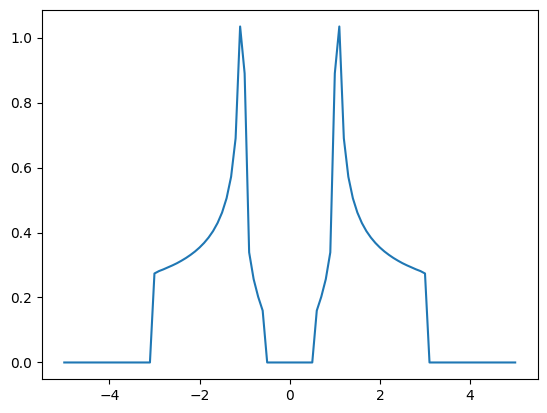

{'Energy': <wannierberri.result.kbandresult.KBandResult object at 0x78c44c49d910>}


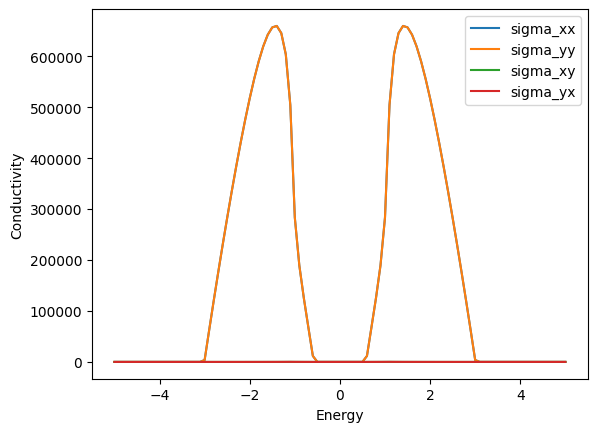

In [16]:
plt.plot(Efermi, results.results["dos"].data, label="DOS")
plt.show()
plt.plot(Efermi, results.results["ohmic"].data[:,0,0], label="sigma_xx")
plt.plot(Efermi, results.results["ohmic"].data[:,1,1], label="sigma_yy")
plt.plot(Efermi, results.results["ohmic"].data[:,0,1], label="sigma_xy")
plt.plot(Efermi, results.results["ohmic"].data[:,1,0], label="sigma_yx")
plt.legend()
plt.xlabel('Energy')
plt.ylabel('Conductivity') 

print (results.results["tabulate"].results)
energies = results.results["tabulate"].results["Energy"].data.reshape(NK, NK,-1)

rec_lattive = system.recip_lattice[:2,:2]

np.savez("energies.npz", energies=energies, rec_lattice=rec_lattive)

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (7, 2, 2)
Real-space lattice:
 [[1.        0.        0.       ]
 [0.5       0.8660254 0.       ]
 [0.        0.        1.       ]]
Number of wannier functions: 2
Number of R points: 7
Recommended size of FFT grid [3 3 1]
Reading the system from PythTB finished successfully
(100, 100, 2)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2

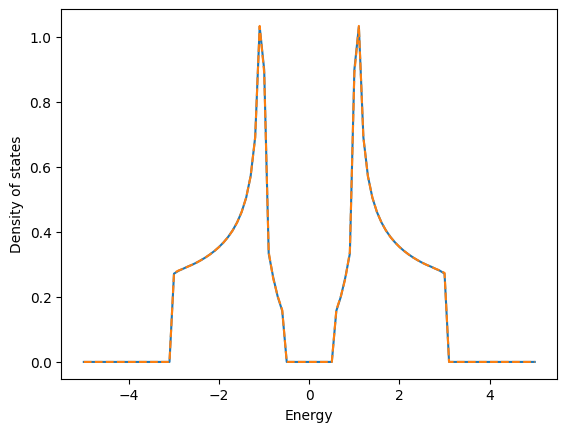

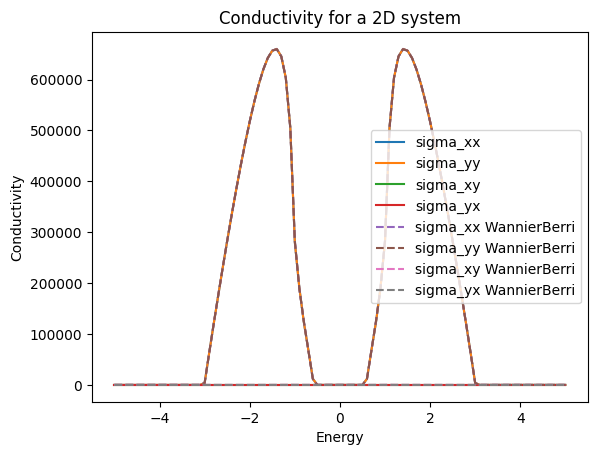

In [ ]:
import os
import numpy as np
from integrateFermi.contours2D import get_kpoints_and_weights_FS
from wannierberri.factors import factor_ohmic
from wannierberri.models import Haldane_ptb
from wannierberri.system import System_PythTB
system = System_PythTB(Haldane_ptb())

result_dos =np.load("result-dos_iter-0000.npz")
Efermi = result_dos["Energies_0"]
dos_wb = result_dos["data"]
result_cond = np.load("result-ohmic_iter-0000.npz")
conductivity_wb = result_cond["data"][:,:2,:2] * system.real_lattice[2,2] 
f = np.load("energies.npz")
E = f["energies"][:,:]
print(E.shape)
rec_lattive = f["rec_lattice"]

dos = np.zeros(len(Efermi))
conductivity = np.zeros((len(Efermi), 2, 2))
os.makedirs("contours", exist_ok=True)

for ib in range(2):
    for i, e in enumerate(Efermi):
        kpoints, weights, grad = get_kpoints_and_weights_FS(E[:,:,ib], rec_lattive, e, gradient=True)
        np.savez(f"contours/contour_ib{ib}_EF={np.round(e,5):.5f}.npz", kpoints=kpoints, weights=weights, grad=grad)
        dos[i] += np.sum(weights)
        conductivity[i] += np.einsum('i,ia,ib->ab', weights, grad, grad)

conductivity *= factor_ohmic * np.linalg.det(rec_lattive) / (2*np.pi)**2
import matplotlib.pyplot as plt
plt.plot(Efermi, dos, label='DOS contours')
plt.plot(Efermi, dos_wb, label="DOS WannierBerri", linestyle='dashed')
plt.xlabel('Energy')
plt.ylabel('Density of states')
plt.title(f'Density of states for a 2D system')
plt.legend()
plt.show()

plt.plot(Efermi, conductivity[:,0,0], label='sigma_xx contours')
plt.plot(Efermi, conductivity[:,1,1], label='sigma_yy contours')
plt.plot(Efermi, conductivity[:,0,1], label='sigma_xy contours')
plt.plot(Efermi, conductivity[:,1,0], label='sigma_yx contours')
plt.plot(Efermi, conductivity_wb[:,0,0], label='sigma_xx WannierBerri', linestyle='dashed')
plt.plot(Efermi, conductivity_wb[:,1,1], label='sigma_yy WannierBerri', linestyle='dashed')
plt.plot(Efermi, conductivity_wb[:,0,1], label='sigma_xy WannierBerri', linestyle='dashed')
plt.plot(Efermi, conductivity_wb[:,1,0], label='sigma_yx WannierBerri', linestyle='dashed')
plt.xlabel('Energy')
plt.ylabel('Conductivity')
plt.title(f'Conductivity for a 2D system')
plt.legend()
plt.show()

In [4]:
import glob
import numpy as np
from integrateFermi.get_band_wavefunction import get_wavefunction_on_kpoints
for f in glob.glob("contours/contour_ib*_EF=*.npz"):
    data = np.load(f)
    kpoints = data["kpoints"]
    weights = data["weights"]
    ib = int(f.split("contour_ib")[1].split("_EF=")[0])
    wavefunctions = get_wavefunction_on_kpoints(
                        system=system, 
                        kpoints=kpoints, 
                        ibands=ib)
    np.savez(f.replace(".npz", "_wavefunctions.npz"), 
             kpoints=kpoints,
             weights=weights,
             wavefunctions=wavefunctions)


TypeError: object of type 'int' has no len()

In [1]:
import numpy as np
from integrateFermi.contours2D import get_contours_and_WFs
from wannierberri.models import Haldane_ptb
from wannierberri.system import System_PythTB
import ray
# ray.init()
system = System_PythTB(Haldane_ptb())
get_contours_and_WFs(system=system,
                     grid=50,
                     save_dir="contours",
                     )

/home/stepan/github/Triangles/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-17 19:07:48,895	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (7, 2, 2)
Real-space lattice:
 [[1.        0.        0.       ]
 [0.5       0.8660254 0.       ]
 [0.        0.        1.       ]]
Number of wannier functions: 2
Number of R points: 7
Recommended size of FFT grid [3 3 1]
Reading the system from PythTB finished successfully
loaded energies_grid and rec_lattice from file
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (0, 2)
weight.shape= (0,)
grad.shape= (2, 0)
k_center.shape= (21, 2)
weight.shape= (21,)
grad.shape= (2, 21)
k_center.shape= (21, 2)
weight.shape= (21,)
grad.shape= (2, 21)
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x7f21193e08f0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
-----

/home/stepan/github/Triangles/.conda/lib/python3.12/site-packages/wannierberri/run.py:219: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/Triangles/.conda/lib/python3.12/site-packages/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


ValueError: operands could not be broadcast together with shapes (2,) (3,) 

In [6]:
res.results["wavefunction"].data.shape

(737, 2, 1)

In [10]:
import numpy as np
f  = np.load("./wb/elements_wannier.npz")
print (list(f.keys()))

['V']


In [9]:
import glob
for f in glob.glob("./wb/*.npz"):
    print(f)
    s = np.load(f)
    print(list(s.keys()))

./wb/elements_wannier.npz
['V']
./wb/wse2.amn.npz
['NK', 'data_0', 'data_1', 'data_2', 'data_3', 'data_4', 'data_5', 'data_6', 'data_7', 'data_8', 'data_9', 'data_10', 'data_11', 'data_12', 'data_13', 'data_14', 'data_15', 'data_16', 'data_17', 'data_18', 'data_19', 'data_20', 'data_21', 'data_22', 'data_23', 'data_24', 'data_25', 'data_26', 'data_27', 'data_28', 'data_29', 'data_30', 'data_31', 'data_32', 'data_33', 'data_34', 'data_35']
./wb/wse2.win.npz
['seedname', 'spinors', 'write_hr', 'write_xyz', 'num_bands', 'guiding_centres', 'write_u_matrices', 'num_wann', 'num_iter', 'dis_froz_max', 'dis_froz_min', 'dis_num_iter', 'dis_mix_ratio', 'mp_grid', 'unit_cell_cart', 'kpoints', 'projections', 'atoms_frac', 'atoms_names']
./wb/wse2.chk.npz
['mp_grid', 'real_lattice', 'num_wann', 'num_bands', 'num_kpts', 'kpt_red', 'wannier_centers_cart', 'wannier_spreads', 'v_matrix_0', 'v_matrix_1', 'v_matrix_2', 'v_matrix_3', 'v_matrix_4', 'v_matrix_5', 'v_matrix_6', 'v_matrix_7', 'v_matrix_8', 'v

In [11]:
V  = np.load("./wb/elements_wannier.npz")["V"]
V.shape


(36, 36, 22, 22)